# Build `db_filtered.parq` — the cutout index the photometry runs on

Data-preparation notebook (formerly `spherex_summary_v5.ipynb`).  Reads the full SPHEREx
cutout index `db.parq` on the T7 SSD (`directory.DB_DIR`), keeps the exposures with
predicted `vmag < 22` and `r_hel < 20 au`, attaches each cutout's `RA-OBJ`, `DEC-OBJ` and
serialised WCS read from the FITS headers, and writes `db_filtered.parq` beside it.  The
photometry pipeline (`spherex_apphot.fitsio.load_database`) reads that file with predicate
pushdown.  The two histograms go to `fig/apphot/`.

Run once per data release; slow (reads ~139 000 FITS headers).

In [1]:
import sys
from pathlib import Path
import re
import pandas as pd
from tqdm import tqdm

# project root (holds spherex_apphot/) and notebooks/ (holds the shared rcparams.py)
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "spherex_apphot" / "__init__.py").is_file())
for _p in (ROOT, ROOT / "notebooks"):
    sys.path.insert(0, str(_p))
import rcparams  # noqa: F401  (project figure style)
from spherex_apphot import directory

from astropy.io import fits
from astropy.wcs import WCS

import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval
from matplotlib.gridspec import GridSpec

In [2]:
fpath_db = directory.DB_DIR / "db.parq"
data_summary = pd.read_parquet(fpath_db)

# colnames = ["objdesig", "r_hel", "r_obs", "alpha", "vmag", "wl", "jd_utc"]
# data_summary = df_db[colnames]

data_summary.info()
data_summary.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535399 entries, 0 to 535398
Columns: 239 entries, objdesig to VXYZ_SC_SYSTEM
dtypes: float64(132), int64(49), object(58)
memory usage: 976.3+ MB


,objdesig,obsid,detector,wl,wlwidth,sun_jy,xcen,ycen,ltv1,ltv2,...,X_SC_END,X_SC_START,Y_SC,Y_SC_END,Y_SC_START,Z_SC,Z_SC_END,Z_SC_START,XYZ_SC_SYSTEM,VXYZ_SC_SYSTEM
0,2003 O1,2025W18_2B_0486_2,6,4.764365,0.037079,3.233220e+13,44.59375,44.65625,-1131,-723,...,-3553.279458,-3917.136732,4850.534078,4716.589984,4966.198189,-3474.414812,-3839.125827,-3096.575152,GEOCENTER,GEOCENTER
1,2011 Q1,2025W18_2B_0445_1,2,1.334514,0.031799,2.297718e+14,44.75000,44.71875,-1258,-990,...,2951.178157,2468.609256,-1730.444181,-2038.136065,-1421.495333,-6264.777257,-6060.716905,-6441.528634,GEOCENTER,GEOCENTER
2,2020 R7,2025W18_2B_0461_3,2,1.557030,0.038086,2.180676e+14,44.96875,44.68750,-344,-258,...,-3223.189277,-2768.208942,2099.785293,2393.308707,1798.295029,5988.087799,5759.306736,6194.088950,GEOCENTER,GEOCENTER
3,1992 Q2,2025W18_2B_0461_3,2,1.301795,0.031204,2.347505e+14,45.28125,44.78125,-1404,-1119,...,-3223.189277,-2768.208942,2099.785293,2393.308707,1798.295029,5988.087799,5759.306736,6194.088950,GEOCENTER,GEOCENTER
4,138P,2025W18_2B_0136_4,2,1.606261,0.038879,2.125917e+14,45.31250,44.75000,-504,-98,...,4476.146657,4556.394390,-5379.817021,-5413.668125,-5325.556547,-145.052897,283.842659,-573.397167,GEOCENTER,GEOCENTER
5,2018 B1,2025W18_2B_0136_4,2,1.279753,0.030258,2.373859e+14,44.59375,45.31250,-177,-1227,...,4476.146657,4556.394390,-5379.817021,-5413.668125,-5325.556547,-145.052897,283.842659,-573.397167,GEOCENTER,GEOCENTER
6,2002 EJ57,2025W18_2B_0136_4,2,1.484425,0.037079,2.222848e+14,45.06250,44.87500,-616,-474,...,4476.146657,4556.394390,-5379.817021,-5413.668125,-5325.556547,-145.052897,283.842659,-573.397167,GEOCENTER,GEOCENTER
7,2012 A1,2025W18_2B_0001_4,1,0.935169,0.024307,2.487698e+14,45.06250,45.21875,-1529,-830,...,4351.226212,4181.193216,-4564.873176,-4744.133868,-4368.367854,-3228.715421,-2842.758869,-3602.442691,GEOCENTER,GEOCENTER
8,2012 A1,2025W18_2B_0001_4,4,3.138426,0.091309,7.238042e+13,45.15625,44.81250,-1532,-818,...,4351.226212,4181.193216,-4564.873176,-4744.133868,-4368.367854,-3228.715421,-2842.758869,-3602.442691,GEOCENTER,GEOCENTER
9,2012 A1,2025W18_2B_0001_2,1,0.891903,0.022415,2.482868e+14,44.68750,44.75000,-1533,-1061,...,3882.049964,3575.595711,-3559.364517,-3809.730347,-3295.592459,-4790.561137,-4470.135445,-5092.895687,GEOCENTER,GEOCENTER


In [3]:
r_hel_max = 20
vmag_max = 22

mask = (data_summary["vmag"] < vmag_max) & (data_summary["r_hel"] < r_hel_max)
data_summary_filtered = data_summary[mask].copy()

data_summary_filtered.info()
data_summary_filtered.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 103774 entries, 2 to 535370
Columns: 239 entries, objdesig to VXYZ_SC_SYSTEM
dtypes: float64(132), int64(49), object(58)
memory usage: 190.0+ MB


,objdesig,obsid,detector,wl,wlwidth,sun_jy,xcen,ycen,ltv1,ltv2,...,X_SC_END,X_SC_START,Y_SC,Y_SC_END,Y_SC_START,Z_SC,Z_SC_END,Z_SC_START,XYZ_SC_SYSTEM,VXYZ_SC_SYSTEM
2,2020 R7,2025W18_2B_0461_3,2,1.557030,0.038086,2.180676e+14,44.96875,44.68750,-344,-258,...,-3223.189277,-2768.208942,2099.785293,2393.308707,1798.295029,5988.087799,5759.306736,6194.088950,GEOCENTER,GEOCENTER
11,245P,2025W18_2B_0028_4,2,1.270495,0.030716,2.382538e+14,45.40625,44.87500,-1144,-1228,...,-3318.953507,-3670.756089,5042.621859,4900.335451,5167.887804,-3451.744542,-3817.357360,-3066.333026,GEOCENTER,GEOCENTER
12,245P,2025W18_2B_0028_4,5,4.022299,0.036499,4.599855e+13,44.59375,44.75000,-1148,-1217,...,-3318.953507,-3670.756089,5042.621859,4900.335451,5167.887804,-3451.744542,-3817.357360,-3066.333026,GEOCENTER,GEOCENTER
26,93P,2025W18_2B_0447_3,4,3.314004,0.096497,6.553139e+13,44.75000,44.78125,-1964,-624,...,4651.085960,4734.994895,-5225.378645,-5258.127862,-5173.186857,-76.062670,360.336545,-504.655897,GEOCENTER,GEOCENTER
33,2023 A3,2025W18_2B_0003_4,3,2.345249,0.058990,1.183640e+14,45.03125,45.40625,-166,-163,...,2357.732520,2810.154903,-4270.645176,-4049.653345,-4475.405211,4932.253719,5224.809759,4620.900892,GEOCENTER,GEOCENTER
34,2023 A3,2025W18_2B_0003_4,6,4.947930,0.037781,2.990931e+13,44.68750,45.12500,-165,-154,...,2357.732520,2810.154903,-4270.645176,-4049.653345,-4475.405211,4932.253719,5224.809759,4620.900892,GEOCENTER,GEOCENTER
39,2023 A3,2025W18_2B_0003_3,3,2.292244,0.056213,1.233444e+14,45.28125,44.78125,-166,-279,...,2870.018246,3273.289897,-4712.397347,-4529.524391,-4877.357526,4197.191780,4530.848186,3847.538221,GEOCENTER,GEOCENTER
40,2023 A3,2025W18_2B_0003_3,6,4.911654,0.037445,3.036613e+13,45.15625,45.37500,-165,-269,...,2870.018246,3273.289897,-4712.397347,-4529.524391,-4877.357526,4197.191780,4530.848186,3847.538221,GEOCENTER,GEOCENTER
43,2023 A3,2025W18_2B_0003_2,3,2.241189,0.055786,1.282461e+14,45.12500,45.12500,-166,-394,...,3319.179116,3666.282008,-5056.610513,-4914.798853,-5179.201726,3392.301162,3759.987088,3011.686210,GEOCENTER,GEOCENTER
44,2023 A3,2025W18_2B_0003_2,6,4.875890,0.036377,3.082363e+13,45.25000,44.62500,-165,-385,...,3319.179116,3666.282008,-5056.610513,-4914.798853,-5179.201726,3392.301162,3759.987088,3011.686210,GEOCENTER,GEOCENTER


In [4]:
FITS_DIR = directory.FITS_DIR

# 1. Compile a Regex pattern to safely extract the keys from the filenames
# This handles the tricky part: obsid contains underscores, so simple .split('_') is risky.
pattern = re.compile(
    r"^(?P<objdesig>.*?)_.*?(?:um)_.*?(?:Vmag)_(?P<obsid>.*)_(?P<detector>\d+)\.fits$"
)

# 2. Build a high-speed lookup dictionary from the actual files on disk
filename_lookup = {}

print("Scanning FITS directory to build filename index...")
for file_path in FITS_DIR.glob("*.fits"):
    match = pattern.match(file_path.name)
    if match:
        # Create a tuple key: (objdesig, obsid, detector)
        # We cast detector to string here to ensure it matches Pandas data types safely
        key = (
            match.group("objdesig"), 
            match.group("obsid"), 
            str(match.group("detector"))
        )
        filename_lookup[key] = file_path.name

# 3. Map the matched filenames back to your summary DataFrame
def get_filename(row):
    # Ensure we are passing strings to match the dictionary keys
    key = (str(row['objdesig']), str(row['obsid']), str(row['detector']))
    return filename_lookup.get(key, None)  # Returns None if no matching file exists

print("Mapping filenames to data_summary...")
data_summary_filtered['filename'] = data_summary_filtered.apply(get_filename, axis=1)

# Inspect the results
matched_count = data_summary_filtered['filename'].notna().sum()
print(f"Matched {matched_count} out of {len(data_summary_filtered)} rows.")

data_summary_filtered[['objdesig', 'obsid', 'detector', 'filename']].head(10)

Scanning FITS directory to build filename index...
Mapping filenames to data_summary...
Matched 103774 out of 103774 rows.


,objdesig,obsid,detector,filename
2,2020 R7,2025W18_2B_0461_3,2,2020 R7_1.5570um_20.39Vmag_2025W18_2B_0461_3_2...
11,245P,2025W18_2B_0028_4,2,245P_1.2705um_21.76Vmag_2025W18_2B_0028_4_2.fits
12,245P,2025W18_2B_0028_4,5,245P_4.0223um_21.76Vmag_2025W18_2B_0028_4_5.fits
26,93P,2025W18_2B_0447_3,4,93P_3.3140um_20.59Vmag_2025W18_2B_0447_3_4.fits
33,2023 A3,2025W18_2B_0003_4,3,2023 A3_2.3452um_14.68Vmag_2025W18_2B_0003_4_3...
34,2023 A3,2025W18_2B_0003_4,6,2023 A3_4.9479um_14.68Vmag_2025W18_2B_0003_4_6...
39,2023 A3,2025W18_2B_0003_3,3,2023 A3_2.2922um_14.68Vmag_2025W18_2B_0003_3_3...
40,2023 A3,2025W18_2B_0003_3,6,2023 A3_4.9117um_14.68Vmag_2025W18_2B_0003_3_6...
43,2023 A3,2025W18_2B_0003_2,3,2023 A3_2.2412um_14.68Vmag_2025W18_2B_0003_2_3...
44,2023 A3,2025W18_2B_0003_2,6,2023 A3_4.8759um_14.68Vmag_2025W18_2B_0003_2_6...


In [5]:
# Add columns for RA-OBJ, DEC-OBJ, and WCS_SERIALIZED
for idx, row in tqdm(data_summary_filtered.iterrows(), total=data_summary_filtered.shape[0], desc="Extracting WCS info"):
    
    fpath_fits = FITS_DIR / row.filename
    hdr = fits.getheader(fpath_fits, ext=1)
    
    ra_obj = hdr['RA-OBJ']
    dec_obj = hdr['DEC-OBJ']
    wcs_serialized = WCS(hdr).to_header_string(relax=True)

    data_summary_filtered.loc[idx, 'RA-OBJ'] = ra_obj
    data_summary_filtered.loc[idx, 'DEC-OBJ'] = dec_obj
    data_summary_filtered.loc[idx, 'WCS_SERIALIZED'] = wcs_serialized

# Remove WCS-related columns from the summary DataFrame to reduce memory usage
wcs_patterns = [
    r"^RADESYS$", r"^WCSAXES$",
    r"^CRPIX\d$", r"^CRVAL\d$", r"^CTYPE\d$", r"^CUNIT\d$", r"^CDELT\d$",
    r"^PC\d_\d$", r"^LONPOLE$", r"^LATPOLE$",
    r"^PV\d_\d+$",                     # PV Distortion coefficients
    r"^[AB]_ORDER$", r"^[AB]_\d_\d$",  # SIP Forward Distortion (A/B)
    r"^[AB]P_ORDER$", r"^[AB]P_\d_\d$" # SIP Reverse Distortion (AP/BP)
]
wcs_cols = [
    col for col in data_summary_filtered.columns 
    if any(re.match(pattern, col) for pattern in wcs_patterns)
]
data_summary_filtered = data_summary_filtered.drop(columns=wcs_cols)
data_summary_filtered.info()
data_summary_filtered.head(10)

Extracting WCS info:   4%|▍         | 3917/103774 [01:38<42:01, 39.60it/s]  


KeyboardInterrupt: 

In [6]:
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import re

# 1. Define a lightweight worker function to handle a single file
def fetch_wcs_data(filename):
    try:
        fpath_fits = FITS_DIR / filename
        # getheader reads only the header bytes, avoiding the heavy image data array
        hdr = fits.getheader(fpath_fits, ext=1)
        
        ra_obj = hdr.get('RA-OBJ', None)
        dec_obj = hdr.get('DEC-OBJ', None)
        wcs_serialized = WCS(hdr).to_header_string(relax=True)
        
        return ra_obj, dec_obj, wcs_serialized
    except Exception as e:
        # Return safely if a file is missing or corrupted
        return None, None, None

# 2. Extract filenames to a raw Python list to bypass Pandas iteration overhead
filenames = data_summary_filtered['filename'].tolist()

# 3. Blast through the disk I/O bottleneck using 16 simultaneous threads
print(f"Spinning up parallel threads to read {len(filenames)} FITS files...")
with ThreadPoolExecutor(max_workers=16) as executor:
    # executor.map automatically preserves the exact order of the list
    results = list(tqdm(
        executor.map(fetch_wcs_data, filenames), 
        total=len(filenames), 
        desc="Extracting WCS Info"
    ))

# 4. Unpack the results into separate lists
ra_list, dec_list, wcs_list = zip(*results)

# 5. Assign lists to the DataFrame instantly (bypasses the SettingWithCopyWarning)
data_summary_filtered = data_summary_filtered.copy() # Guarantee it's completely detached
data_summary_filtered['RA-OBJ'] = ra_list
data_summary_filtered['DEC-OBJ'] = dec_list
data_summary_filtered['WCS_SERIALIZED'] = wcs_list

# 6. Safely drop the unnecessary WCS columns
wcs_patterns = [
    r"^RADESYS$", r"^WCSAXES$",
    r"^CRPIX\d$", r"^CRVAL\d$", r"^CTYPE\d$", r"^CUNIT\d$", r"^CDELT\d$",
    r"^PC\d_\d$", r"^LONPOLE$", r"^LATPOLE$",
    r"^PV\d_\d+$",                     # PV Distortion coefficients
    r"^[AB]_ORDER$", r"^[AB]_\d_\d$",  # SIP Forward Distortion (A/B)
    r"^[AB]P_ORDER$", r"^[AB]P_\d_\d$" # SIP Reverse Distortion (AP/BP)
]

wcs_cols = [
    col for col in data_summary_filtered.columns 
    if any(re.match(pattern, col) for pattern in wcs_patterns)
]

data_summary_filtered = data_summary_filtered.drop(columns=wcs_cols)

print("Done! DataFrame updated.")
data_summary_filtered.info()

/Users/bumhoo7/miniconda3/envs/spherex/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Spinning up parallel threads to read 103774 FITS files...


Extracting WCS Info:   2%|▏         | 1628/103774 [00:47<49:14, 34.58it/s] 


KeyboardInterrupt: 

In [19]:
data_summary_filtered.to_parquet(directory.DB_DIR / "db_filtered.parq", index=False)
# data_summary_filtered.to_csv(directory.RESULT_DIR / "spherex_summary_v5.csv", index=False)

In [20]:
data_summary_filtered.value_counts("objdesig").head(10)

objdesig
2014 UN271    3178
2024 N1       2193
2024 W1       1491
2023 V1       1243
161P           994
2025 L1        841
2023 H5        809
306P           783
24P            765
1999 RO28      595
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 105P to 9P
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   r_hel   445 non-null    float64
 1   vmag    445 non-null    float64
dtypes: float64(2)
memory usage: 10.4+ KB


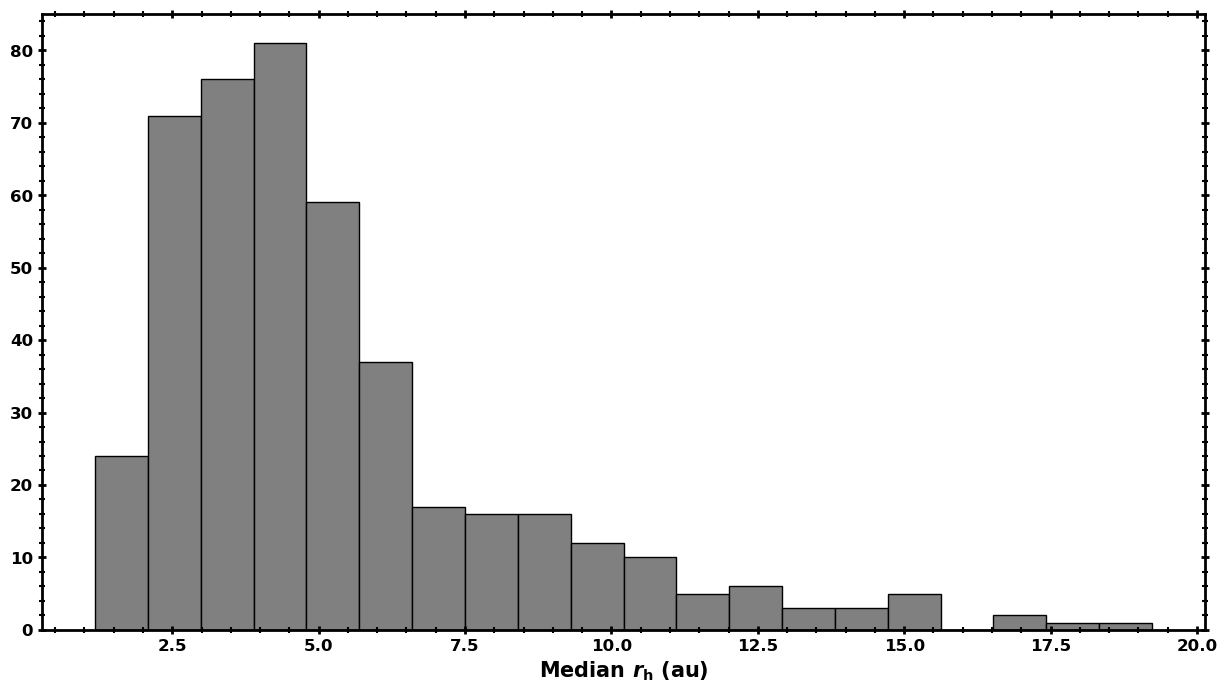

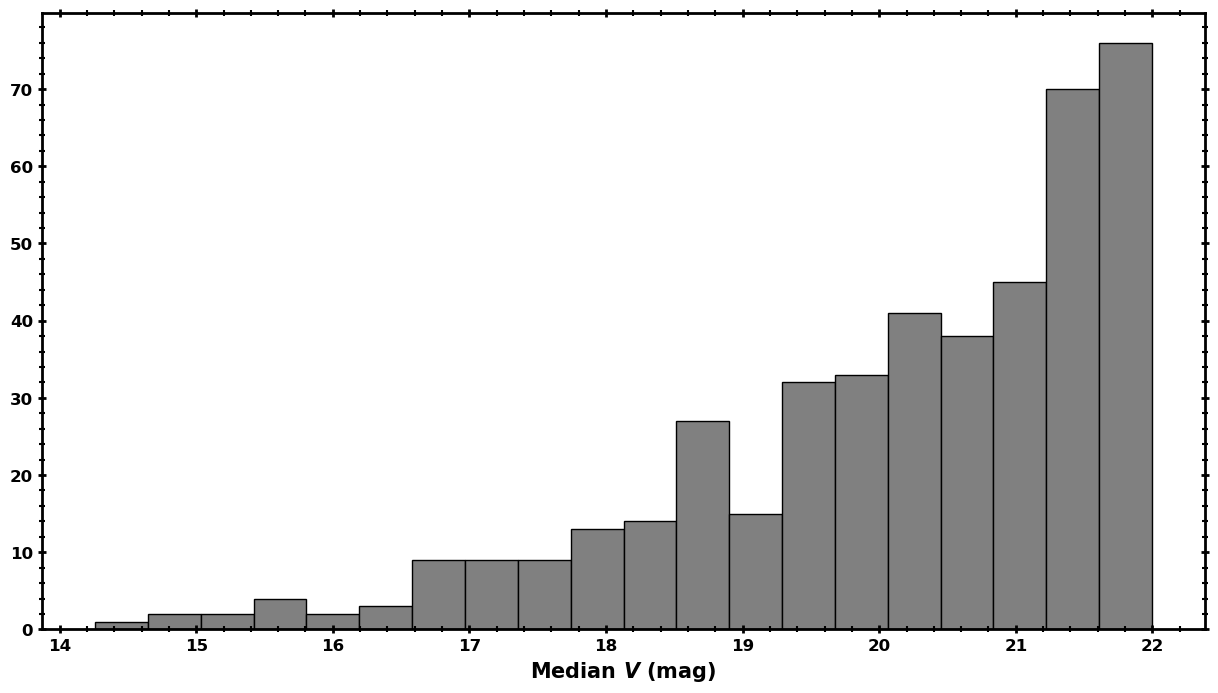

In [21]:
data_summary_gp = data_summary_filtered.groupby("objdesig").agg({"r_hel": "median", "vmag": "median"})
data_summary_gp.info()

fig = plt.figure()
ax = fig.add_subplot()  
ax.hist(data_summary_gp["r_hel"], bins=20, color='gray', edgecolor='black')
ax.set_xlabel(r"Median ${r_\mathrm{h}}$ (au)")
plt.savefig(directory.FIG_DIR / "spherex_summary_v5_rhel_hist.png")
plt.show()

fig = plt.figure()
ax = fig.add_subplot()
ax.hist(data_summary_gp["vmag"], bins=20, color='gray', edgecolor='black')
ax.set_xlabel(r"Median $V$ (mag)")
plt.savefig(directory.FIG_DIR / "spherex_summary_v5_vmag_hist.png") 
plt.show()

In [ ]:
list_fpaths_fits = list(data_summary_filtered["filename"].dropna().apply(lambda x: FITS_DIR / x))

# Filter out the Mac metadata files from the list
list_fpaths_fits = [p for p in list_fpaths_fits if not p.name.startswith("._")]
list_fpaths_fits.sort()

print(f"Total FITS files found: {len(list_fpaths_fits)}")
list_fpaths_fits[:5]

Total FITS files found: 103774


[PosixPath('/Volumes/T7/data/spherex-comet/comets_v5_fits/105P_0.7411um_20.08Vmag_2025W41_2B_0394_3_1.fits'),
 PosixPath('/Volumes/T7/data/spherex-comet/comets_v5_fits/105P_0.7495um_19.82Vmag_2025W40_1A_0139_3_1.fits'),
 PosixPath('/Volumes/T7/data/spherex-comet/comets_v5_fits/105P_0.7581um_20.08Vmag_2025W41_2B_0394_4_1.fits'),
 PosixPath('/Volumes/T7/data/spherex-comet/comets_v5_fits/105P_0.7619um_20.12Vmag_2025W42_1A_0047_1_1.fits'),
 PosixPath('/Volumes/T7/data/spherex-comet/comets_v5_fits/105P_0.7795um_20.12Vmag_2025W42_1A_0047_2_1.fits')]

In [23]:
fpath_fits = list_fpaths_fits[0]
hdul = fits.open(fpath_fits)
hdul.info()
hdul[1].header

Filename: /Volumes/T7/data/spherex-comet/comets_v5_fits/105P_0.7411um_20.08Vmag_2025W41_2B_0394_3_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1  IMAGE         1 ImageHDU       202   (91, 91)   float32   
  2  VARIANCE      1 ImageHDU         8   (91, 91)   float32   
  3  FLAG          1 ImageHDU         8   (91, 91)   int32   


XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   91                                                  
NAXIS2  =                   91                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'IMAGE   '           / extension name                                 
WLWIDTH =   0.0169219970703125                                                  
AP3_RAD =                  3.0                                                  
AP3_SUM = -0.05137751085673514                                                  
AP3_ERR =  0.18764336987609875                                                  
AP4_RAD =    2.9916080351831